# RavenStack SaaS Product, Revenue & Churn Analysis
## Notebook 3: Business Insights

This notebook pulls together the cleaning (Notebook 1) and statistics (Notebook 2) work into
business-facing churn, revenue and support insights, using simple grouping and `CASE WHEN`-style
segmentation in Pandas (`pd.cut`, boolean masks). No modelling - just clear, explainable analysis.

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snssns.set_style('whitegrid')master = pd.read_csv('../data/processed/master_account_table.csv')print(master.shape)print(master['status'].value_counts())

(500, 30)statusRetained    390Churned     110Name: count, dtype: int64

## 1. Churn rate by segment

In [ ]:
def churn_rate_by(col):    g = master.groupby(col)['status'].apply(lambda s: (s=='Churned').mean()*100).round(2)    n = master.groupby(col).size()    return pd.DataFrame({'churn_rate_pct': g, 'n_accounts': n}).sort_values('churn_rate_pct', ascending=False)churn_rate_by('industry')

                churn_rate_pct  n_accountsindustry                                 DevTools                30.97         113FinTech                 22.32         112HealthTech              21.88          96EdTech                  16.46          79Cybersecurity           16.00         100

In [ ]:
churn_rate_by('referral_source')

                  churn_rate_pct  n_accountsreferral_source                            event                     30.21          96other                     24.27         103ads                       23.47          98organic                   17.54         114partner                   14.61          89

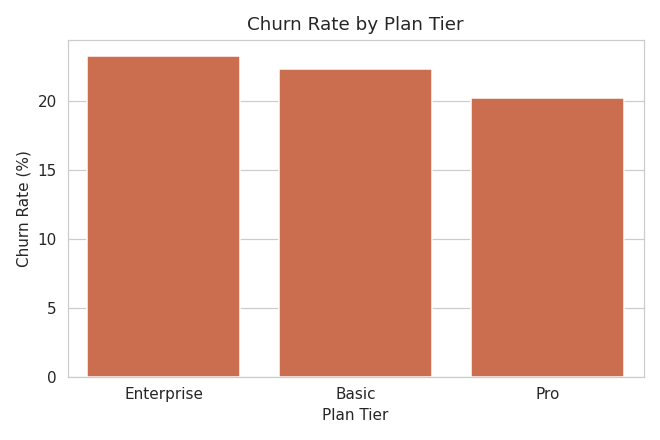

In [ ]:
plt.figure(figsize=(7,4))cbp = churn_rate_by('current_plan_tier')sns.barplot(x=cbp.index, y=cbp['churn_rate_pct'], color='#e0623a')plt.title('Churn Rate by Plan Tier'); plt.ylabel('Churn Rate (%)'); plt.xlabel('Plan Tier')plt.tight_layout()plt.show()

In [ ]:
churn_rate_by('billing_frequency')

                    churn_rate_pct  n_accountsbilling_frequency                            annual                      24.55         277monthly                     18.83         223

**Observations (use cautious language - "associated with", not "causes"):**
- Churn rate is highest in **DevTools (30.97%)** and lowest in **Cybersecurity (16.00%)** and **EdTech (16.46%)** - about a 15-point spread across industries, the largest gap we see in this analysis.
- Accounts acquired through **events (30.21%)** churn noticeably more than accounts from **partner referrals (14.61%)**.
- **Annual billing (24.55%)** shows a slightly higher churn rate than **monthly billing (18.83%)** - counter-intuitive, since annual contracts are usually considered "stickier". This is worth a closer look (it may reflect contract non-renewal being logged as churn at the annual boundary) rather than assuming annual plans are worse.
- Plan tier, account size and auto-renewal setting show only small differences in churn rate (all within about 3 percentage points of each other) - none of these look like a strong standalone churn driver, which lines up with the hypothesis testing in Notebook 2.

## 2. Churn reasons

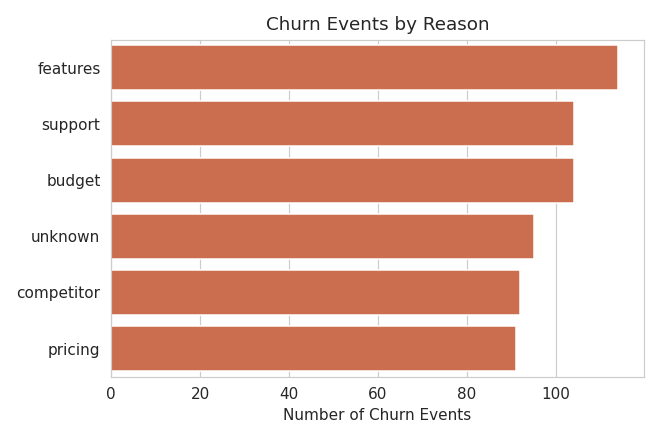

In [ ]:
churn = pd.read_csv('../data/raw/ravenstack_churn_events.csv')reasons = churn['reason_code'].value_counts()plt.figure(figsize=(7,4))sns.barplot(x=reasons.values, y=reasons.index, color='#e0623a')plt.title('Churn Events by Reason'); plt.xlabel('Number of Events'); plt.ylabel('')plt.tight_layout()plt.show()

The top reported churn reasons are **features** (114 events), **support** (104) and **budget** (104) - fairly evenly spread, with no single dominant reason. This suggests churn at RavenStack is driven by several different factors rather than one fixable root cause.

## 3. Usage segment vs churn

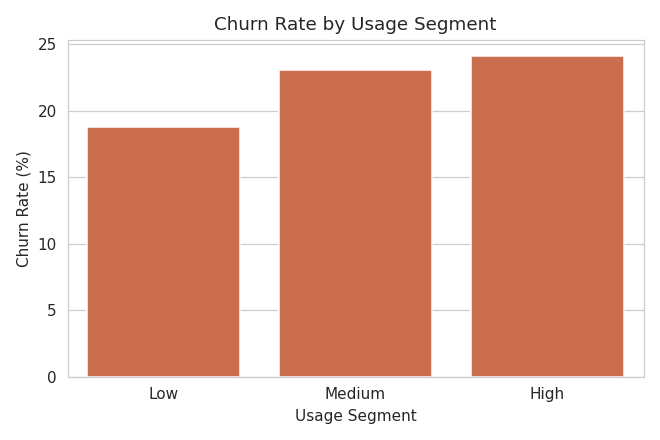

In [ ]:
plt.figure(figsize=(7,4))cus = churn_rate_by('usage_segment').reindex(['Low','Medium','High'])sns.barplot(x=cus.index, y=cus['churn_rate_pct'], color='#e0623a')plt.title('Churn Rate by Usage Segment'); plt.ylabel('Churn Rate (%)'); plt.xlabel('Usage Segment')plt.tight_layout()plt.show()

Churn rate rises only slightly from Low usage (18.8%) to High usage (24.1%) accounts - the opposite direction of the common assumption that "more usage means safer from churn." Combined with the non-significant t-test from Notebook 2, we conclude usage segment is **not** a reliable churn predictor in this dataset.

## 4. Support experience vs churn

In [ ]:
support_summary = master.groupby('status')[['n_tickets','avg_resolution_hours','avg_satisfaction','n_escalations']].mean().round(2)support_summary

          n_tickets  avg_resolution_hours  avg_satisfaction  n_escalationsstatus                                                                    Churned        4.05                 24.51              3.02           0.75Retained       3.95                 24.44              3.03           0.71

Support metrics are nearly identical between churned and retained customers - consistent with the hypothesis test result in Notebook 2 (no statistically significant satisfaction difference). Support experience alone does not explain churn in this dataset.

## 5. Simple customer segmentation (rule-based, using CASE WHEN logic via `pd.cut`)

In [ ]:
segment_summary = master.groupby(['mrr_segment','usage_segment'], observed=True).size().unstack(fill_value=0)segment_summary

usage_segment  Low  Medium  Highmrr_segment                     High MRR        56      57    56Low MRR         52      54    62Medium MRR      57      54    52

MRR segment and usage segment are spread almost evenly against each other - i.e. high-paying accounts are not necessarily the heaviest product users, and vice versa. This reinforces the earlier finding that usage and revenue are only weakly related in this dataset.

## Summary of Notebook 3 - Key Business Findings
1. Industry and referral source show the widest churn-rate spreads (DevTools & event-sourced accounts churn more).
2. Churn reasons are spread fairly evenly across features, support and budget - no single dominant cause.
3. Usage segment, plan tier, account size and auto-renewal setting are **not** strong standalone churn predictors.
4. Support ticket volume, resolution time and satisfaction are nearly identical between churned and retained accounts.
5. MRR and usage segments are largely independent of each other.

These findings feed directly into the recommendations in the final report.